In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df_night = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/csvfiles/05-02-2026/00.05.csv")
df_day   = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/csvfiles/05-02-2026/12.05.csv")
AfterPulse = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/AfterPulse.csv")
AfterPulse

,range_m,afterpulse_counts_per_bin,afterpulse_raw
0,0.00,0.0,0.0
1,3.75,0.0,0.0
2,7.50,0.0,0.0
3,11.25,0.0,0.0
4,15.00,0.0,0.0
...,...,...,...
4495,16856.25,NaN,NaN
4496,16860.00,NaN,NaN
4497,16863.75,NaN,NaN
4498,16867.50,NaN,NaN


In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10001.25,
    "bg_end_m": 14996.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [3]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75

import numpy as np

bin_spacing_m = 3.75

def process_lidar_full_pipeline(df, afterpulse_df, config, bin_spacing_m=3.75, blend_extend_m=100):
    df = df.copy()

    # =========================
    # 0) Add bin index and range
    # =========================
    if "bin_index" in df.columns:
        df = df.drop(columns=["bin_index"])
    if "range_m" in df.columns:
        df = df.drop(columns=["range_m"])

    df.insert(0, "bin_index", np.arange(len(df)))
    df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

    # =========================
    # 1) Signal-to-noise ratio
    # =========================
    df["SNR_analog"] = df["analog"] / (df["analog_sterr"] + 1e-12)
    df["SNR_Photon"] = df["photon_counting"] / (df["pc_sterr"] + 1e-12)

    # =========================
    # 2) Convert MHz -> photon per bin
    # =========================
    df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

    # =========================
    # 3) Background region
    # =========================
    bg_row = df[
        (df["range_m"] >= config["bg_start_m"]) &
        (df["range_m"] <= config["bg_end_m"])
    ]

    Analog_bg_mean = bg_row["analog"].mean()
    Photon_bg_mean = bg_row["photon_per_bin"].mean()

    print("Analog background (mean):", Analog_bg_mean)
    print("Photon Per Bin background (mean):", Photon_bg_mean)

    # Background correction
    df["analog_bg_corr"] = df["analog"] - Analog_bg_mean
    df["Photon_per_bin_bg_corr"] = df["photon_per_bin"] - Photon_bg_mean

    # =========================
    # 4) Afterpulse correction
    # =========================
    # if len(afterpulse_df) != len(df):
    #     raise ValueError(
    #         f"Length mismatch: afterpulse_df has {len(afterpulse_df)} rows, "
    #         f"but df has {len(df)} rows"
    #     )

    # df["afterpulse_raw"] = afterpulse_df["afterpulse_raw"].to_numpy()
    # df["afterpulse_counts_per_bin"] = (
    #     df["afterpulse_raw"] * config["bin_width_ns"] * 1e-3
    # )

    # df["photon_APcorr_counts"] = (
    #     df["Photon_per_bin_bg_corr"] - df["afterpulse_counts_per_bin"]
    # )

    # =========================
    # 5) Dead-time correction
    # =========================
    bin_width_s = config["bin_width_ns"] * 1e-9
    dead_time_s = config["dead_time_ns"] * 1e-9

    # counts/bin -> rate (Hz)
    rate_meas_hz = df["Photon_per_bin_bg_corr"] / bin_width_s
    ratio = rate_meas_hz * dead_time_s

    # Non-paralyzable correction
    df["photon_deadtime_corr_hz"] = np.where(
        ratio < 1,
        rate_meas_hz / (1 - ratio),
        np.nan
    )

    # Hz -> counts/bin
    df["photon_deadtime_corr"] = df["photon_deadtime_corr_hz"] * bin_width_s

    # =========================
    # 6) Overlap region for gluing
    # =========================
    m_overlap = df[
        (df["range_m"] >= config["overlap_r1_m"]) &
        (df["range_m"] <= config["overlap_r2_m"])
    ].copy()

    # ใช้ photon ที่ corrected แล้วสำหรับ glue
    m_overlap = m_overlap.replace([np.inf, -np.inf], np.nan)
    m_overlap = m_overlap.dropna(subset=["analog_bg_corr", "Photon_per_bin_bg_corr"])

    x = m_overlap["analog_bg_corr"].to_numpy()
    y = m_overlap["Photon_per_bin_bg_corr"].to_numpy()

    if len(x) < 2:
        raise ValueError("Not enough valid points in overlap region for linregress.")

    k_scale, b_offset, r_lin, *_ = linregress(x, y)

    print("k_scale =", k_scale)
    print("b_offset =", b_offset)
    print("R^2 =", r_lin**2)

    # Scale analog to photon domain
    df["analog_scaled_for_glue"] = k_scale * df["analog_bg_corr"] + b_offset

    # =========================
    # 7) Smooth blending weights
    # =========================
    blend_r1_m = config["overlap_r1_m"] - blend_extend_m
    blend_r2_m = config["overlap_r2_m"] + blend_extend_m

    r = df["range_m"].to_numpy()
    w = np.zeros_like(r, dtype=float)

    # far range -> photon full weight
    w[r > blend_r2_m] = 1.0

    # blend region -> cosine
    m = (r >= blend_r1_m) & (r <= blend_r2_m)
    w[m] = 0.5 * (
        1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m))
    )

    df["weight_w"] = w

    # =========================
    # 8) Merge analog + photon
    # =========================
    df["merged_counts_per_bin"] = (
        (1.0 - df["weight_w"]) * df["analog_scaled_for_glue"]
        + df["weight_w"] * df["Photon_per_bin_bg_corr"]
    )

    # =========================
    # 9) Range-square correction
    # =========================
    df["range2_corrected_counts"] = (
        df["merged_counts_per_bin"] * df["range_m"]**2
    )

    # =========================
    # 10) Normalize
    # =========================
    max_val = df["range2_corrected_counts"].max()

    if np.isfinite(max_val) and max_val != 0:
        df["range2_norm"] = df["range2_corrected_counts"] / max_val
    else:
        df["range2_norm"] = np.nan

    return df

df_day = process_lidar_full_pipeline(df_day, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_night = process_lidar_full_pipeline(df_night, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)

print(df_day.head())
print(df_night.head())

Analog background (mean): 16.103118454613654
Photon Per Bin background (mean): 3.1096056451612903
k_scale = 0.06508552549884937
b_offset = 0.14725013930955488
R^2 = 0.9425236655029954
Analog background (mean): 3.937772813203301
Photon Per Bin background (mean): 0.0004999157089272318
k_scale = 0.03404755065208143
b_offset = 4.227764997491393
R^2 = 0.5323078592745867
   bin_index  range_m    analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00   27.5342      0.073185       170.050000  0.864430   
1          1     3.75   40.9949      0.110967       174.245000  0.856524   
2          2     7.50   87.7804      0.548879       100.705000  1.258660   
3          3    11.25  241.5140      1.239810         0.771812  0.131297   
4          4    15.00  442.5140      0.987142        23.271800  0.724884   

   overflow_info  SNR_analog  SNR_Photon  photon_per_bin  analog_bg_corr  \
0            0.0  376.226341  196.719225        4.251250       11.431082   
1            0.0  369.4

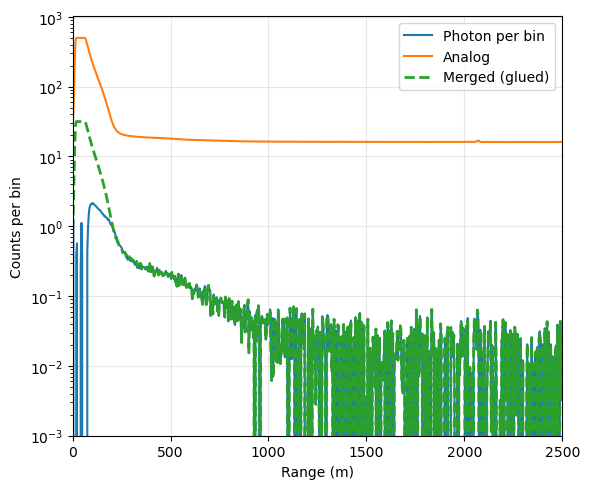

In [4]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df_day["range_m"], df_day["Photon_per_bin_bg_corr"], label="Photon per bin")
ax.plot(df_day["range_m"], df_day["analog"], label="Analog")
ax.plot(df_day["range_m"], df_day["merged_counts_per_bin"], "--", linewidth=2, label="Merged (glued)")

# ax.axvspan(blend_r1_m, blend_r2_m, alpha=0.2, label="Blend region")
ax.set_xlabel("Range (m)")
ax.set_xlim(0, 2500) 
ax.set_ylabel("Counts per bin")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)   # avoid log(0) issues
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


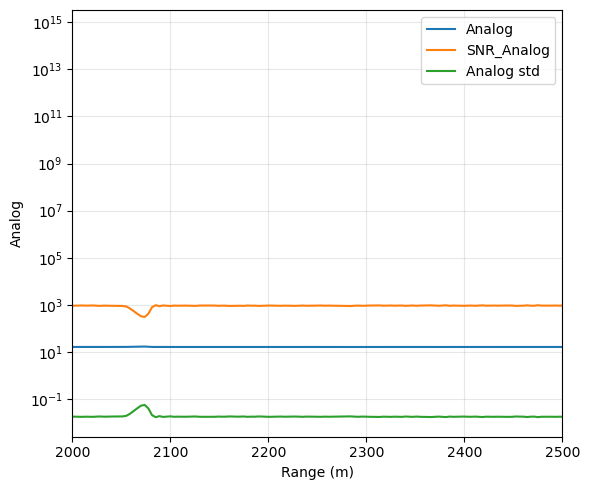

In [5]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df_day["range_m"], df_day["analog"], label="Analog")
ax.plot(df_day["range_m"], df_day["SNR_analog"], label="SNR_Analog")
ax.plot(df_day["range_m"], df_day["analog_sterr"], label="Analog std")
ax.set_xlabel("Range (m)")
ax.set_xlim(2000, 2500) 
ax.set_ylabel("Analog")
ax.set_yscale("log")
# ax.set_ylim(1e1, 1e3)   # avoid log(0) issues
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


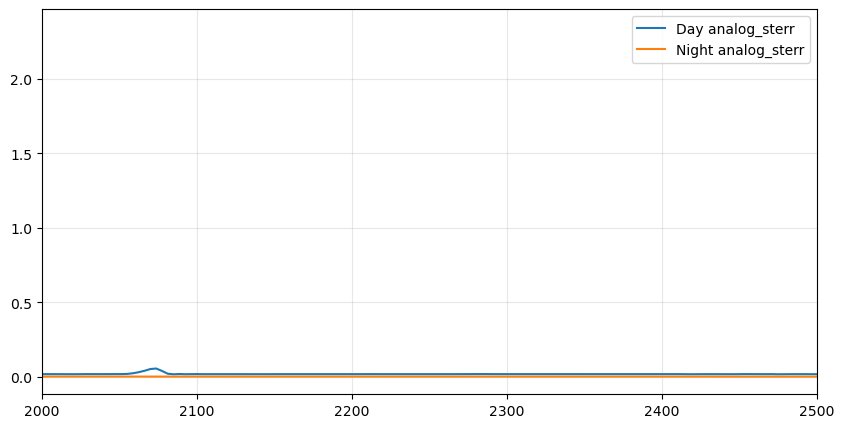

In [6]:
#Check if sterr still present in the same place
plt.figure(figsize=(10,5))

plt.plot(df_day["range_m"], df_day["analog_sterr"], label="Day analog_sterr")
plt.plot(df_night["range_m"], df_night["analog_sterr"], label="Night analog_sterr")

plt.xlim(2000, 2500)
# plt.ylim(None, None)
plt.yscale("linear")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

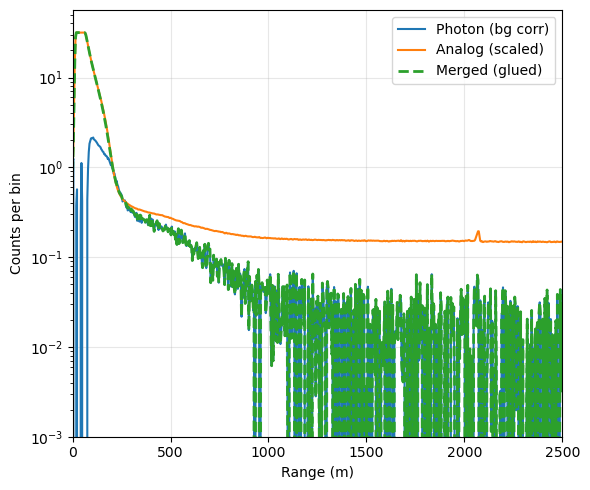

In [7]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df_day["range_m"], df_day["Photon_per_bin_bg_corr"], label="Photon (bg corr)")
ax.plot(df_day["range_m"], df_day["analog_scaled_for_glue"], label="Analog (scaled)")
ax.plot(df_day["range_m"], df_day["merged_counts_per_bin"], "--", linewidth=2, label="Merged (glued)")

# ax.axvspan(blend_r1_m, blend_r2_m, alpha=0.2, label="Blend region")
ax.set_xlabel("Range (m)")
ax.set_xlim(0, 2500) 
ax.set_ylabel("Counts per bin")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)   # avoid log(0) issues
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


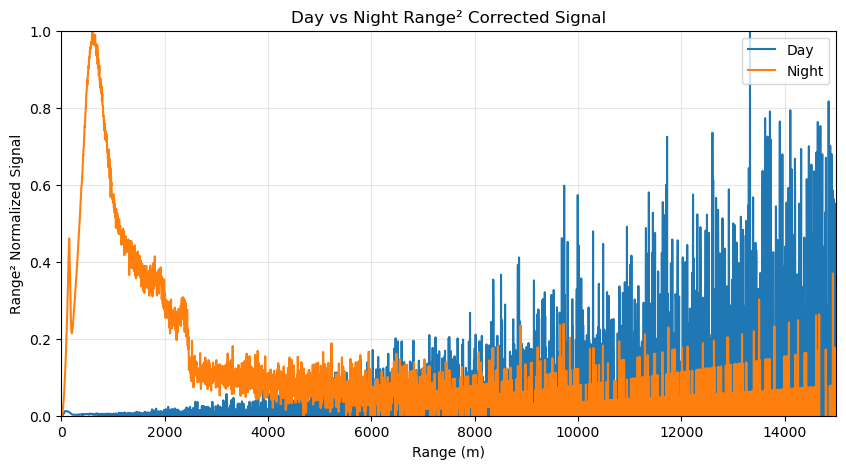

In [8]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(df_day["range_m"], df_day["range2_norm"], label="Day")
ax.plot(df_night["range_m"], df_night["range2_norm"], label="Night")

ax.set_xlabel("Range (m)")
ax.set_ylabel("Range² Normalized Signal")
ax.set_title("Day vs Night Range² Corrected Signal")

ax.set_xlim(0, 15000)
ax.set_ylim(0, 1)

ax.grid(True, alpha=0.3)

# 👉 ตรงนี้
ax.legend(loc="upper right")
plt.savefig(
    "day_vs_night.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

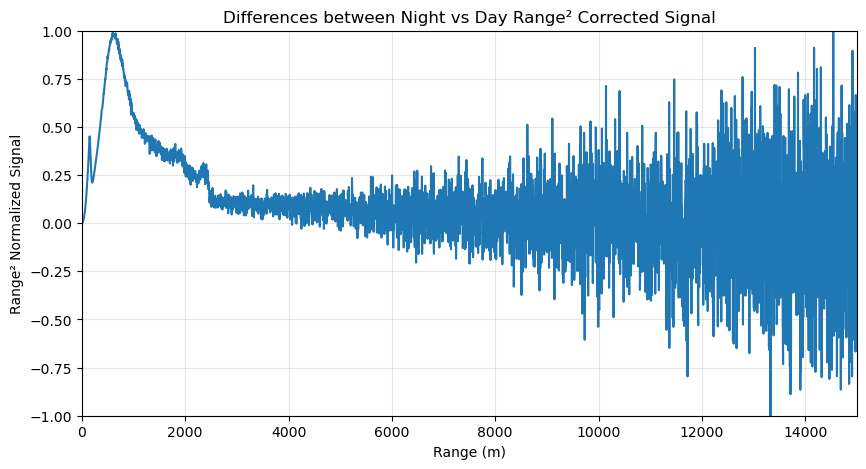

In [35]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(df_day["range_m"], df_night["range2_norm"]-df_day["range2_norm"])
ax.set_xlabel("Range (m)")
ax.set_ylabel("Range² Normalized Signal")
ax.set_title("Differences between Night vs Day Range² Corrected Signal")

ax.set_xlim(0, 15000)
ax.set_ylim(-1, 1)

ax.grid(True, alpha=0.3)

plt.savefig(
    "day_vs_night_Different.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [59]:
df_day.tail()

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,photon_deadtime_corr_hz,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,range2_corrected_counts,range2_norm
3995,3995,14981.25,16.1217,0.0,125.537,0.0,0.0,1.612170e+13,1.255370e+14,3.138425,0.018582,0.028819,1.156855e+06,0.028921,0.148460,1.0,0.028819,6.468154e+06,0.550542
3996,3996,14985.00,16.1095,0.0,123.742,0.0,0.0,1.610950e+13,1.237420e+14,3.093550,0.006382,-0.016056,-6.409662e+05,-0.016024,0.147665,1.0,-0.016056,-3.605299e+06,-0.306868
3997,3997,14988.75,16.1085,0.0,123.893,0.0,0.0,1.610850e+13,1.238930e+14,3.097325,0.005382,-0.012281,-4.904885e+05,-0.012262,0.147600,1.0,-0.012281,-2.759002e+06,-0.234834
3998,3998,14992.50,16.1104,0.0,124.866,0.0,0.0,1.611040e+13,1.248660e+14,3.121650,0.007282,0.012044,4.824855e+05,0.012062,0.147724,1.0,0.012044,2.707271e+06,0.230431
3999,3999,14996.25,16.0944,0.0,123.456,0.0,0.0,1.609440e+13,1.234560e+14,3.086400,-0.008718,-0.023206,-9.255968e+05,-0.023140,0.146683,1.0,-0.023206,-5.218660e+06,-0.444190


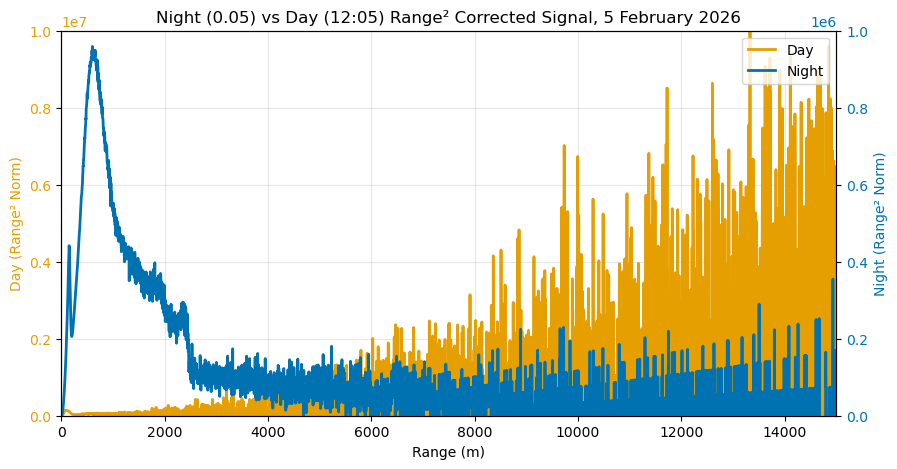

In [75]:
OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000"
}

fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["range2_corrected_counts"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Range² Norm)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["range2_corrected_counts"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Range² Norm)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(0, 15000)
ax1.set_ylim(0, 10000000)
ax2.set_ylim(0, 1000000)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Range² Corrected Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom.png", dpi=300, bbox_inches="tight")

plt.show()

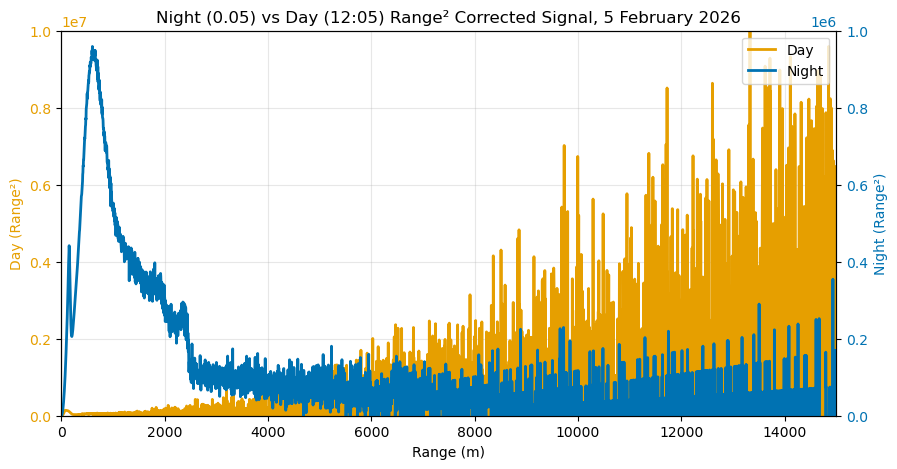

In [123]:
OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000"
}

fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["range2_corrected_counts"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Range²)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["range2_corrected_counts"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Range²)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(0, 15000)
ax1.set_ylim(0, 10000000)
ax2.set_ylim(0, 1000000)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Range² Corrected Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom.png", dpi=300, bbox_inches="tight")

plt.show()

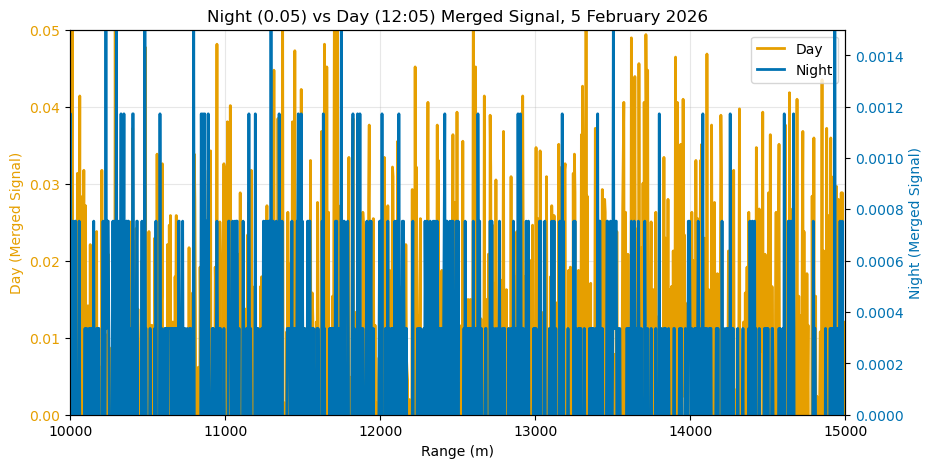

In [107]:
OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000"
}

fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["merged_counts_per_bin"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Merged Signal)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["merged_counts_per_bin"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Merged Signal)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(10000, 15000)
ax1.set_ylim(0, 0.05)
ax2.set_ylim(0, 0.00150)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Merged Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom_bg.png", dpi=300, bbox_inches="tight")

plt.show()

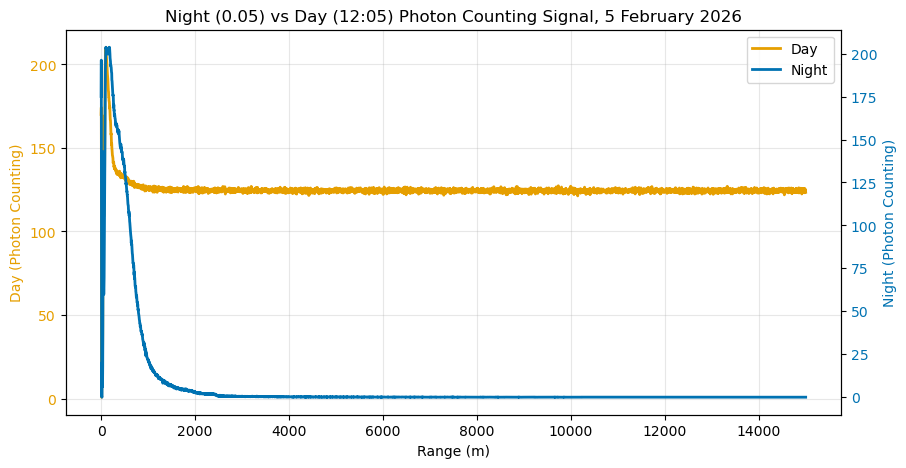

In [127]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["photon_counting"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Photon Counting)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["photon_counting"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Photon Counting)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
# ax1.set_xlim(10000, 15000)
# ax1.set_ylim(0, 0.05)
# ax2.set_ylim(0, 0.00150)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Photon Counting Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom_bg.png", dpi=300, bbox_inches="tight")

plt.show()

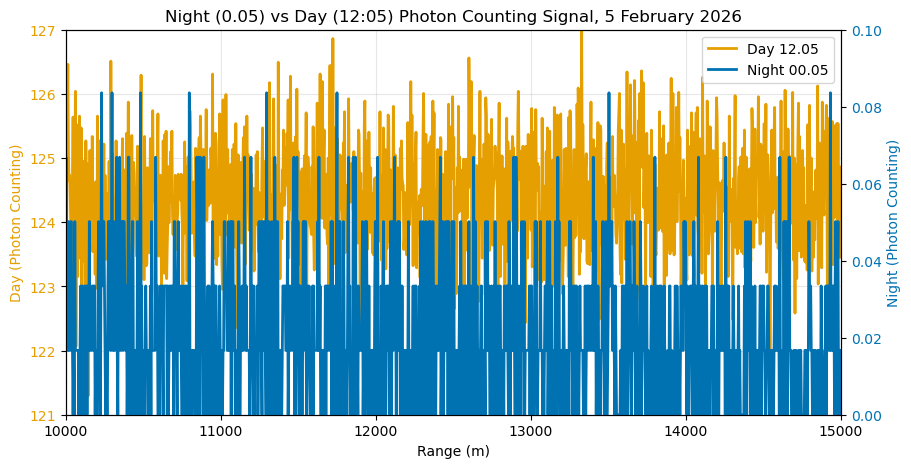

In [143]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["photon_counting"],
    label="Day 12.05",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Photon Counting)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["photon_counting"],
    label="Night 00.05",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Photon Counting)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(10000, 15000)
ax1.set_ylim(121, 127)
ax2.set_ylim(0, 0.1)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Photon Counting Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom_bg.png", dpi=300, bbox_inches="tight")

plt.show()

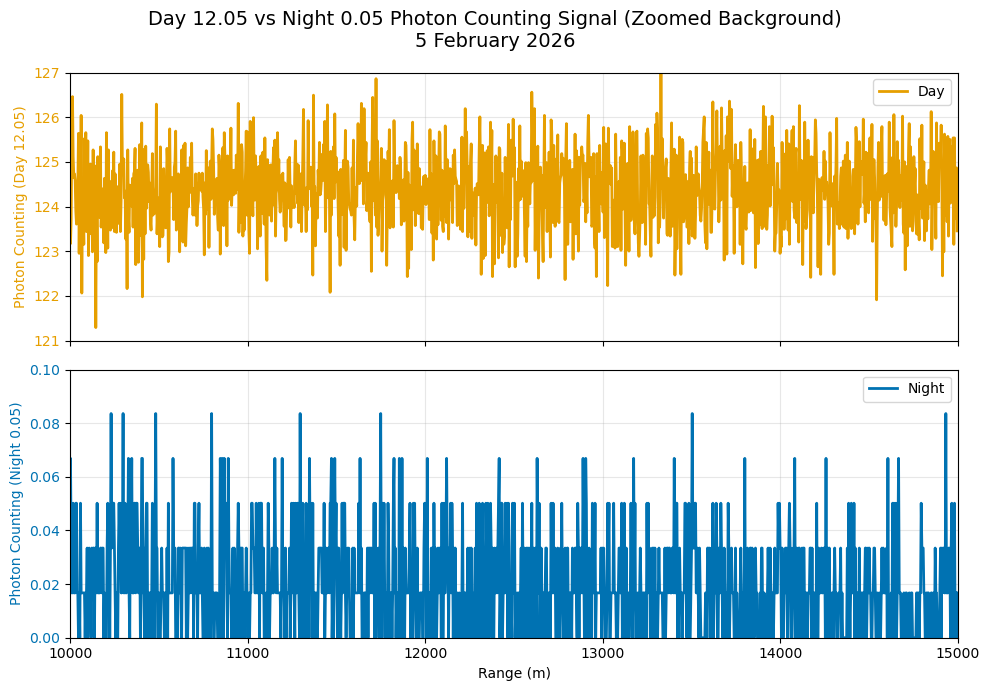

In [149]:
import matplotlib.pyplot as plt

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"
c_night = "#0072B2"

# ---- Create subplots ----
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True   # 👈 สำคัญ! ใช้ range_m เดียวกัน
)

# =========================
# ---- Day plot ----
# =========================
ax1.plot(
    df_day["range_m"],
    df_day["photon_counting"],
    color=c_day,
    linewidth=2,
    label="Day"
)

ax1.set_ylabel("Photon Counting (Day 12.05)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)
ax1.set_ylim(121, 127)

ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# =========================
# ---- Night plot ----
# =========================
ax2.plot(
    df_night["range_m"],
    df_night["photon_counting"],
    color=c_night,
    linewidth=2,
    label="Night"
)

ax2.set_xlabel("Range (m)")
ax2.set_ylabel("Photon Counting (Night 0.05)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)
ax2.set_ylim(0, 0.1)

ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# =========================
# ---- Shared settings ----
# =========================
ax2.set_xlim(10000, 15000)

fig.suptitle(
    "Day 12.05 vs Night 0.05 Photon Counting Signal (Zoomed Background)\n5 February 2026",
    fontsize=14
)

plt.tight_layout()

# ---- Save ----
plt.savefig("day_vs_night_subplot.png", dpi=300, bbox_inches="tight")

plt.show()

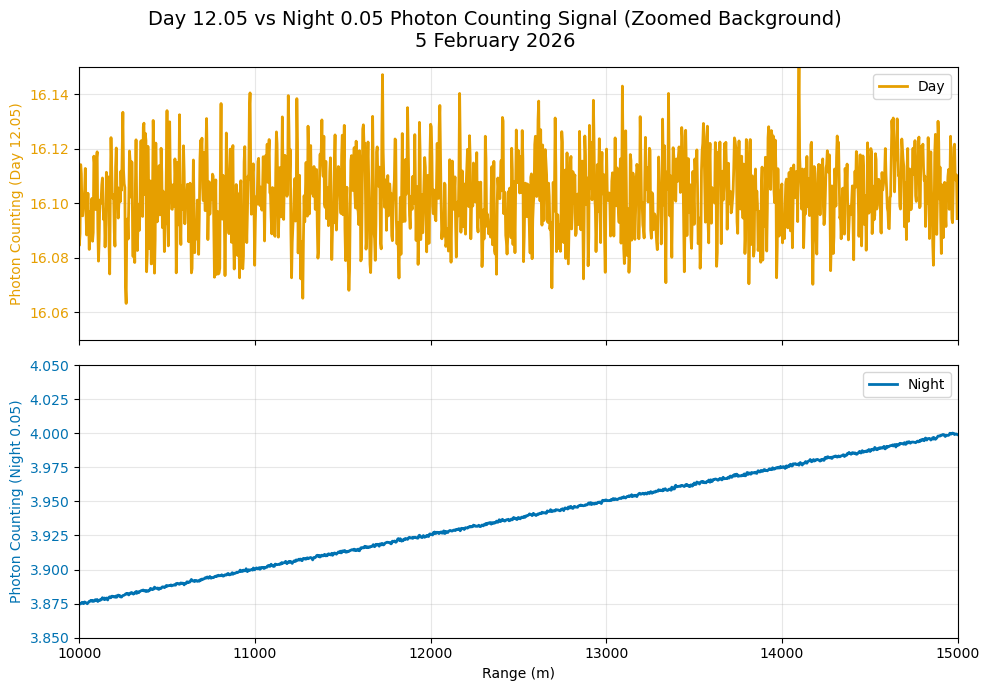

In [167]:
import matplotlib.pyplot as plt

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"
c_night = "#0072B2"

# ---- Create subplots ----
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True   # 👈 สำคัญ! ใช้ range_m เดียวกัน
)

# =========================
# ---- Day plot ----
# =========================
ax1.plot(
    df_day["range_m"],
    df_day["analog"],
    color=c_day,
    linewidth=2,
    label="Day"
)

ax1.set_ylabel("Photon Counting (Day 12.05)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)
ax1.set_ylim(16.05, 16.15)

ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# =========================
# ---- Night plot ----
# =========================
ax2.plot(
    df_night["range_m"],
    df_night["analog"],
    color=c_night,
    linewidth=2,
    label="Night"
)

ax2.set_xlabel("Range (m)")
ax2.set_ylabel("Photon Counting (Night 0.05)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)
ax2.set_ylim(3.85, 4.05)

ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# =========================
# ---- Shared settings ----
# =========================
ax2.set_xlim(10000, 15000)

fig.suptitle(
    "Day 12.05 vs Night 0.05 Photon Counting Signal (Zoomed Background)\n5 February 2026",
    fontsize=14
)

plt.tight_layout()

# ---- Save ----
plt.savefig("day_vs_night_subplot.png", dpi=300, bbox_inches="tight")

plt.show()

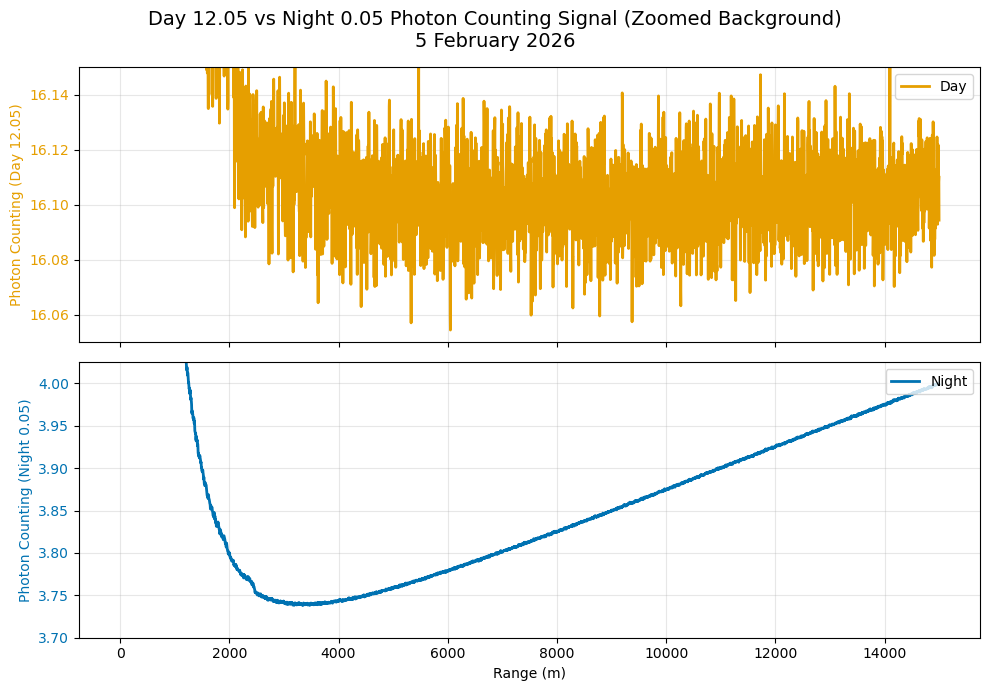

In [173]:
import matplotlib.pyplot as plt

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"
c_night = "#0072B2"

# ---- Create subplots ----
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True   # 👈 สำคัญ! ใช้ range_m เดียวกัน
)

# =========================
# ---- Day plot ----
# =========================
ax1.plot(
    df_day["range_m"],
    df_day["analog"],
    color=c_day,
    linewidth=2,
    label="Day"
)

ax1.set_ylabel("Photon Counting (Day 12.05)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)
ax1.set_ylim(16.05, 16.15)

ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# =========================
# ---- Night plot ----
# =========================
ax2.plot(
    df_night["range_m"],
    df_night["analog"],
    color=c_night,
    linewidth=2,
    label="Night"
)

ax2.set_xlabel("Range (m)")
ax2.set_ylabel("Photon Counting (Night 0.05)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)
ax2.set_ylim(3.70, 4.025)

ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# =========================
# ---- Shared settings ----
# =========================
# ax2.set_xlim(10000, 15000)

fig.suptitle(
    "Day 12.05 vs Night 0.05 Photon Counting Signal (Zoomed Background)\n5 February 2026",
    fontsize=14
)

plt.tight_layout()

# ---- Save ----
plt.savefig("day_vs_night_subplot.png", dpi=300, bbox_inches="tight")

plt.show()

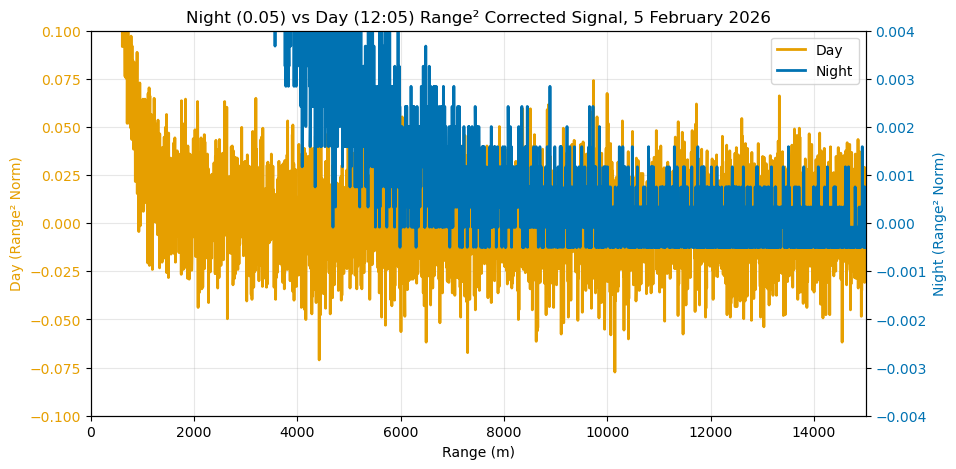

In [117]:
OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000"
}

fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["merged_counts_per_bin"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Range² Norm)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["merged_counts_per_bin"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Range² Norm)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(0, 15000)
ax1.set_ylim(-0.1, 0.1)
ax2.set_ylim(-0.004, 0.004)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Range² Corrected Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom.png", dpi=300, bbox_inches="tight")

plt.show()

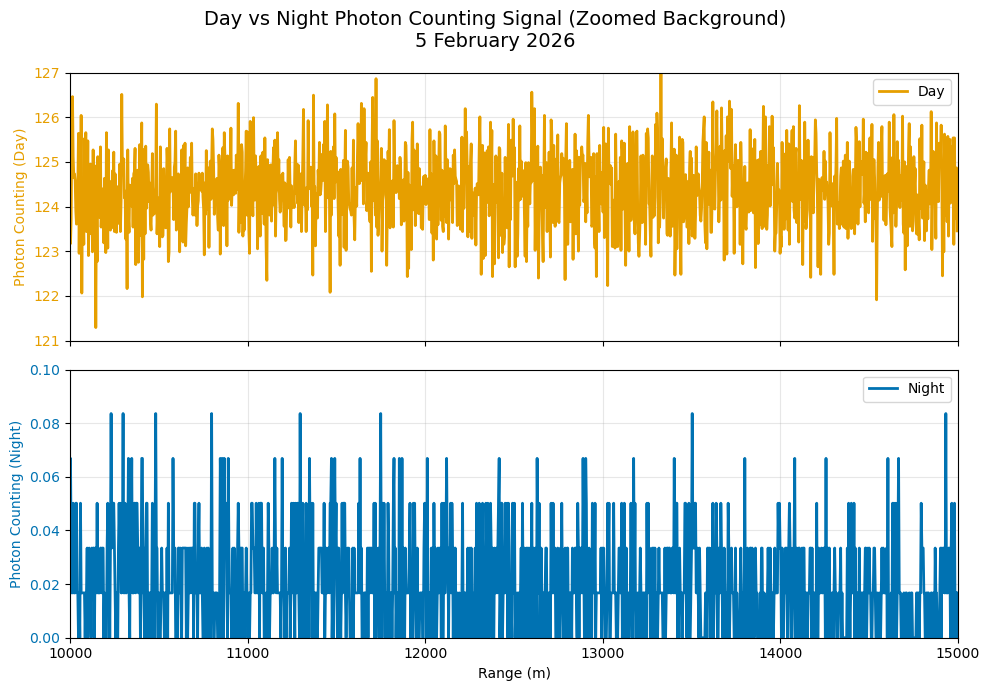

In [141]:
import matplotlib.pyplot as plt

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"
c_night = "#0072B2"

# ---- Create subplots ----
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True   # 👈 สำคัญ! ใช้ range_m เดียวกัน
)

# =========================
# ---- Day plot ----
# =========================
ax1.plot(
    df_day["range_m"],
    df_day["photon_counting"],
    color=c_day,
    linewidth=2,
    label="Day"
)

ax1.set_ylabel("Photon Counting (Day)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)
ax1.set_ylim(121, 127)

ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# =========================
# ---- Night plot ----
# =========================
ax2.plot(
    df_night["range_m"],
    df_night["photon_counting"],
    color=c_night,
    linewidth=2,
    label="Night"
)

ax2.set_xlabel("Range (m)")
ax2.set_ylabel("Photon Counting (Night)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)
ax2.set_ylim(0, 0.1)

ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# =========================
# ---- Shared settings ----
# =========================
ax2.set_xlim(10000, 15000)

fig.suptitle(
    "Day vs Night Photon Counting Signal (Zoomed Background)\n5 February 2026",
    fontsize=14
)

plt.tight_layout()

# ---- Save ----
plt.savefig("day_vs_night_subplot.png", dpi=300, bbox_inches="tight")

plt.show()

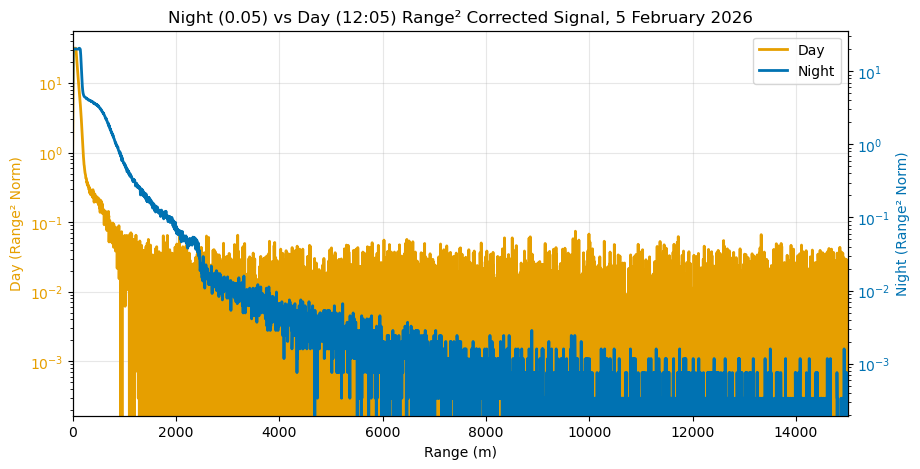

In [121]:
OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000"
}

fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_day["range_m"],
    df_day["merged_counts_per_bin"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Range² Norm)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_night["range_m"],
    df_night["merged_counts_per_bin"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Range² Norm)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(0, 15000)
# ax1.set_ylim(-0.1, 0.1)
# ax2.set_ylim(-0.004, 0.004)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Range² Corrected Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

ax1.set_yscale("log")
ax2.set_yscale("log")

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom.png", dpi=300, bbox_inches="tight")

plt.show()

In [70]:
# fig, ax = plt.subplots(figsize=(10,5))

# x = df_day["range_m"]
# y1 = df_day["range2_norm"]
# y2 = df_night["range2_norm"]

# # ax.plot(x, y1, label="Day")
# # ax.plot(x, y2, label="Night")

# # 👉 Fill the difference
# ax.fill_between(
#     x,
#     y1,
#     y2,
#     color="red",
#     alpha=1,
#     label="Difference"
# )

# ax.set_xlabel("Range (m)")
# ax.set_ylabel("Range² Normalized Signal")
# ax.set_title("Day vs Night Range² Corrected Signal")

# ax.set_xlim(0, 15000)
# ax.set_ylim(0, 1)

# ax.grid(True, alpha=0.3)
# ax.legend(loc="upper right")

# plt.show()

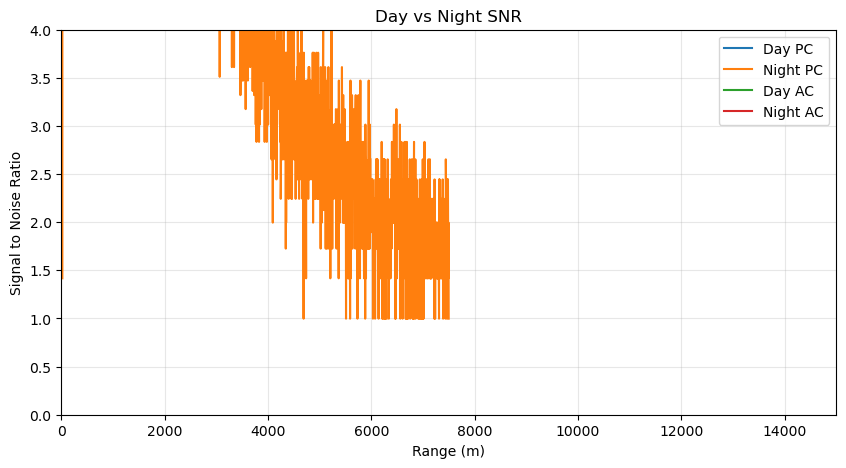

In [38]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(df_day["range_m"], df_day["photon_counting"]/df_day["pc_sterr"], label="Day PC")
ax.plot(df_night["range_m"], df_night["photon_counting"]/df_night["pc_sterr"], label="Night PC")
ax.plot(df_day["range_m"], df_day["analog"]/df_day["analog_sterr"], label="Day AC")
ax.plot(df_night["range_m"], df_night["analog"]/df_night["analog_sterr"], label="Night AC")

ax.set_xlabel("Range (m)")
ax.set_ylabel("Signal to Noise Ratio")
ax.set_title("Day vs Night SNR")
plt.yscale("linear")
ax.set_xlim(0, 15000)
ax.set_ylim(0, 4)
ax.grid(True, alpha=0.3)

# 👉 ตรงนี้
ax.legend(loc="upper right")

plt.show()

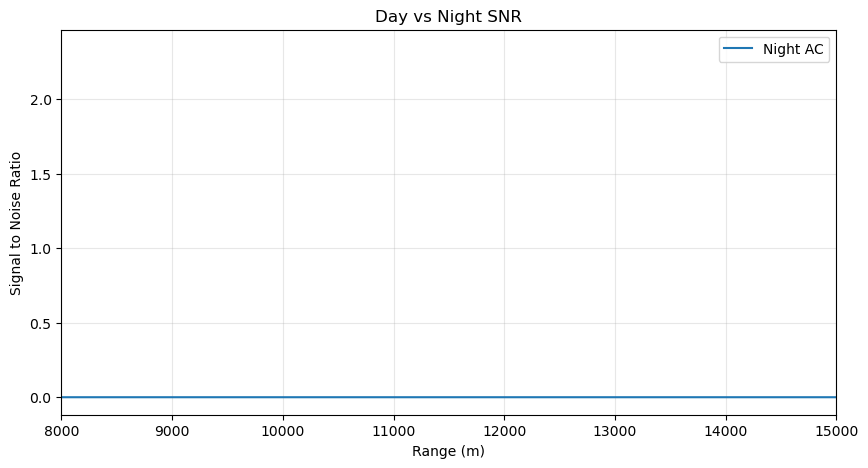

In [62]:
fig, ax = plt.subplots(figsize=(10,5))

# ax.plot(df_day["range_m"], df_day["pc_sterr"], label="Day PC")
# ax.plot(df_night["range_m"], df_night["pc_sterr"], label="Night PC")
# ax.plot(df_day["range_m"], df_day["analog_sterr"], label="Day AC")
ax.plot(df_night["range_m"], df_night["analog_sterr"], label="Night AC")

ax.set_xlabel("Range (m)")
ax.set_ylabel("Signal to Noise Ratio")
ax.set_title("Day vs Night SNR")
plt.yscale("linear")
ax.set_xlim(8000, 15000)

ax.grid(True, alpha=0.3)

# 👉 ตรงนี้
ax.legend(loc="upper right")

plt.show()

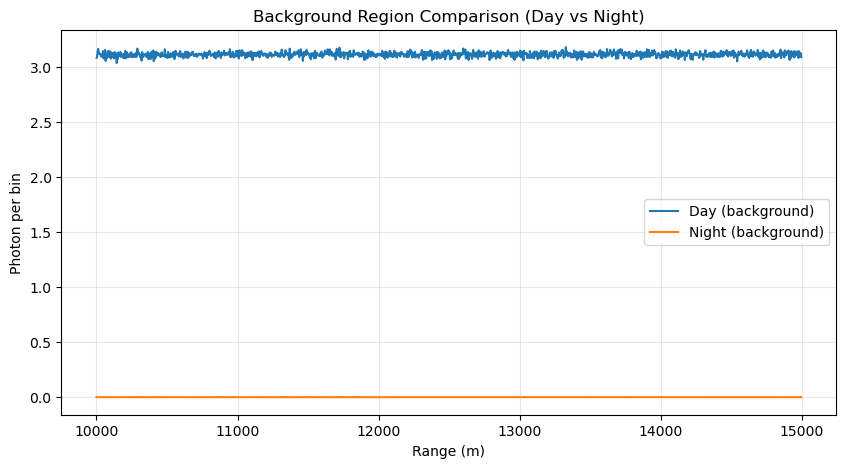

In [10]:
# mask background region
bg_mask_day = (
    (df_day["range_m"] >= config["bg_start_m"]) &
    (df_day["range_m"] <= config["bg_end_m"])
)

bg_mask_night = (
    (df_night["range_m"] >= config["bg_start_m"]) &
    (df_night["range_m"] <= config["bg_end_m"])
)

# plot
plt.figure(figsize=(10,5))

plt.plot(
    df_day.loc[bg_mask_day, "range_m"],
    df_day.loc[bg_mask_day, "photon_per_bin"],
    label="Day (background)",
)

plt.plot(
    df_night.loc[bg_mask_night, "range_m"],
    df_night.loc[bg_mask_night, "photon_per_bin"],
    label="Night (background)",
)

plt.xlabel("Range (m)")
plt.ylabel("Photon per bin")
plt.title("Background Region Comparison (Day vs Night)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()



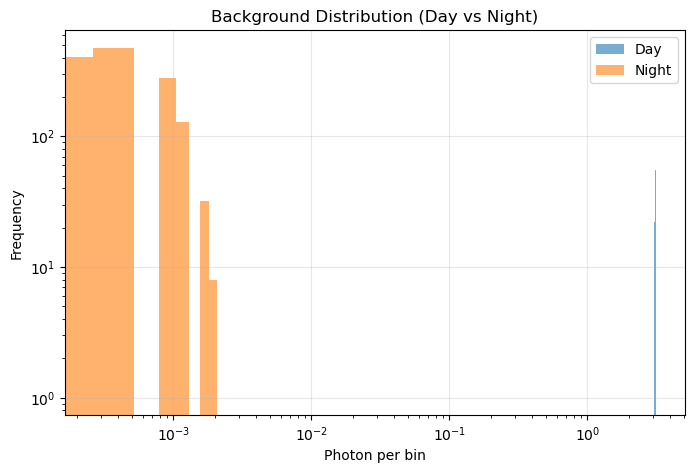

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    df_day.loc[bg_mask_day, "photon_per_bin"],
    bins=50,
    alpha=0.6,
    label="Day"
)

plt.hist(
    df_night.loc[bg_mask_night, "photon_per_bin"],
    bins=8,
    alpha=0.6,
    label="Night"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Photon per bin")
plt.ylabel("Frequency")
plt.title("Background Distribution (Day vs Night)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

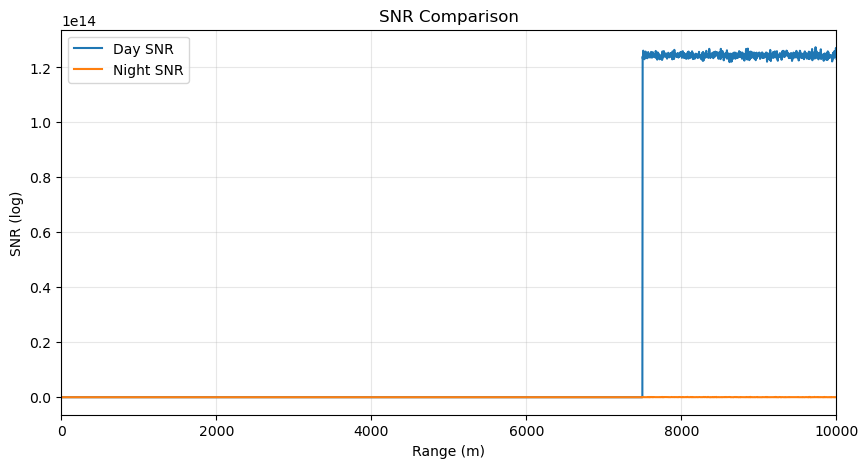

In [12]:
plt.figure(figsize=(10,5))

plt.plot(df_day["range_m"], df_day["SNR_Photon"], label="Day SNR")
plt.plot(df_night["range_m"], df_night["SNR_Photon"], label="Night SNR")

plt.yscale("linear")
plt.xlim(0, 10000)

plt.xlabel("Range (m)")
plt.ylabel("SNR (log)")
plt.title("SNR Comparison")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

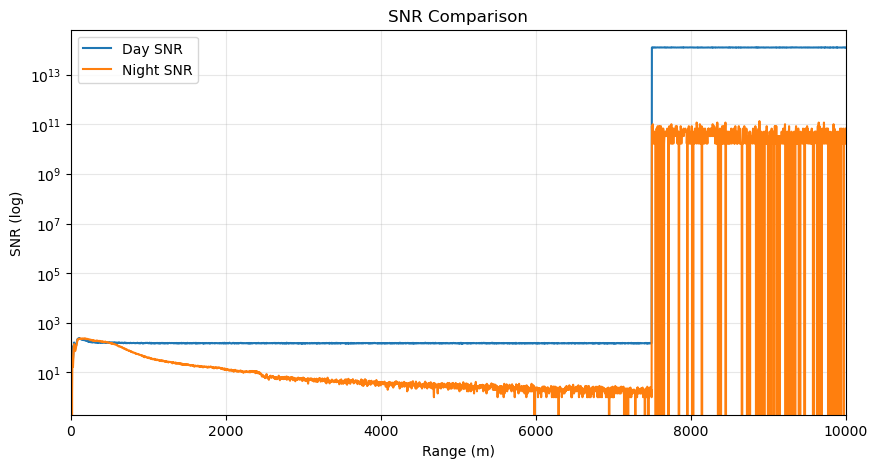

In [13]:
plt.figure(figsize=(10,5))

plt.plot(df_day["range_m"], df_day["SNR_Photon"], label="Day SNR")
plt.plot(df_night["range_m"], df_night["SNR_Photon"], label="Night SNR")

plt.yscale("log")
plt.xlim(0, 10000)

plt.xlabel("Range (m)")
plt.ylabel("SNR (log)")
plt.title("SNR Comparison")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

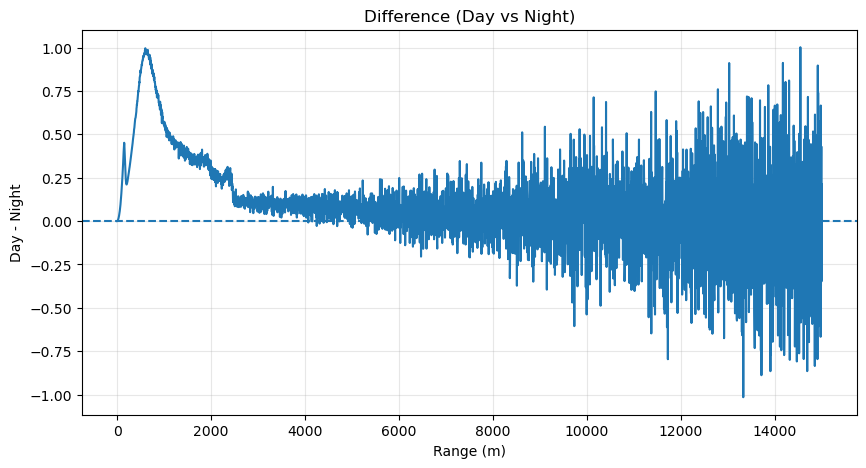

In [14]:
diff = df_night["range2_norm"] - df_day["range2_norm"]

plt.figure(figsize=(10,5))
plt.plot(df_day["range_m"], diff)

plt.axhline(0, linestyle="--")

plt.xlabel("Range (m)")
plt.ylabel("Day - Night")
plt.title("Difference (Day vs Night)")

plt.grid(True, alpha=0.3)

plt.show()

In [15]:
df_night["SNR_Photon"]

0       1.960787e+02
1       2.234301e+02
2       7.899544e+01
3       7.652444e+00
4       0.000000e+00
            ...     
3995    5.016720e+10
3996    0.000000e+00
3997    1.672240e+10
3998    0.000000e+00
3999    1.672240e+10
Name: SNR_Photon, Length: 4000, dtype: float64